In [ ]:
# Student Performance Prediction using Machine Learning

# IBM Generative AI Internship Project

# Developed by: Aradhya Nigam

In [43]:
import pandas as pd

data = pd.read_csv('StudentPerformanceFactors.csv.csv')

data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [44]:
data.shape


(6607, 20)

In [45]:
data.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [46]:
data.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [47]:
data['Teacher_Quality'] = data['Teacher_Quality'].fillna(data['Teacher_Quality'].mode()[0])

data['Parental_Education_Level'] = data['Parental_Education_Level'].fillna(data['Parental_Education_Level'].mode()[0])

data['Distance_from_Home'] = data['Distance_from_Home'].fillna(data['Distance_from_Home'].mode()[0])

In [48]:
data.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [49]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6607 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [50]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


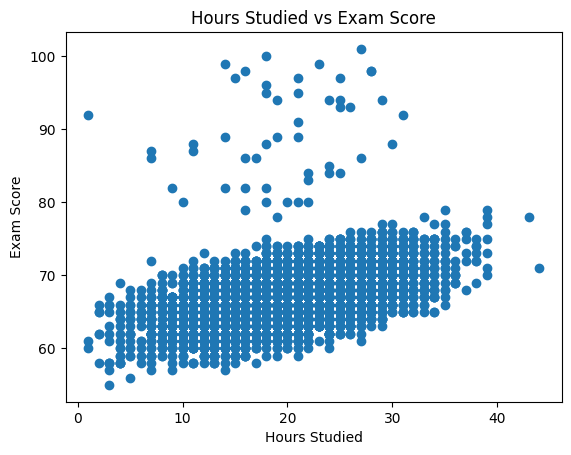

In [51]:
import matplotlib.pyplot as plt

plt.scatter(data['Hours_Studied'], data['Exam_Score'])

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')

plt.show()

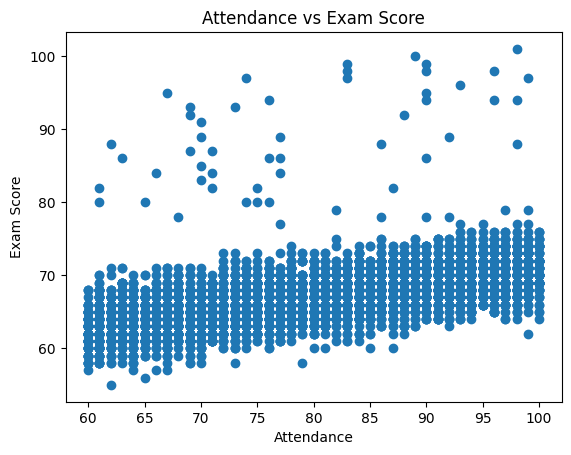

In [52]:
plt.scatter(data['Attendance'], data['Exam_Score'])

plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')

plt.show()

In [53]:
X = data.drop('Exam_Score', axis=1)

y = data['Exam_Score']

In [54]:
X = pd.get_dummies(X, drop_first=True)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](27,)","[ 0.29, 0.2 ,-0.01,..., 0.32, 0.85,-0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](27,)","['Hours_Studied','Attendance','Sleep_Hours',..., 'Distance_from_Home_Moderate','Distance_from_Home_Near','Gender_Male']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.45239200896259923
Root Mean Squared Error: 1.804444509272284
R2 Score: 0.7696495724907312


In [59]:
results = pd.DataFrame({
    'Actual Score': y_test,
    'Predicted Score': y_pred
})

results.head(10)

,Actual Score,Predicted Score
743,65,64.526283
5551,65,65.265114
3442,71,71.531263
6571,64,64.277481
4204,66,66.521653
2516,66,66.612463
4047,72,72.470949
1706,66,66.498269
1075,70,69.986045
233,70,70.133271


In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1.183782148260212
Random Forest RMSE: 2.2332001488200435
Random Forest R2 Score: 0.6471767007776992


In [61]:
data[data['Exam_Score'] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [62]:
data = data[data['Exam_Score'] <= 100]

print("New dataset size:", data.shape)
print("Maximum exam score:", data['Exam_Score'].max())

New dataset size: (6606, 20)
Maximum exam score: 100


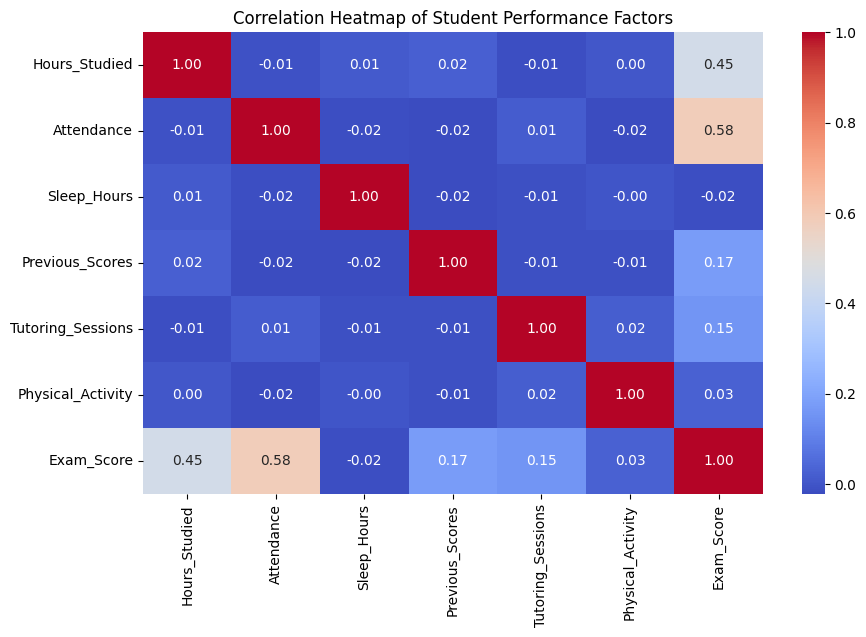

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Student Performance Factors')
plt.show()

In [64]:
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5284, 27)
Testing data: (1322, 27)


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

comparison = pd.DataFrame(results)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.415976,1.521263,0.825000
1,Decision Tree,1.833585,3.674132,-0.020797
2,Random Forest,1.146884,2.012874,0.693618
3,Gradient Boosting,0.769640,1.713829,0.777892


In [66]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross-validation R2 scores:", cv_scores)
print("Average CV R2 score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation R2 scores: [0.62555872 0.74476619 0.70883637 0.73323805 0.83998031]
Average CV R2 score: 0.7304759276550451
Standard deviation: 0.06881706152647472


In [67]:
# Separate numerical and categorical features

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'School_Type_Public', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near', 'Gender_Male']

Number of numerical features: 6
Number of categorical features: 21


In [68]:
# Create fresh features and target from cleaned dataset

X_raw = data.drop('Exam_Score', axis=1)
y_raw = data['Exam_Score']

# Identify original numerical and categorical columns
numerical_features = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numerical features: 6
Number of categorical features: 13


C:\Users\HP\AppData\Local\Temp\ipykernel_5824\3024805132.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_raw.select_dtypes(include=['object']).columns.tolist()


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Pipeline for numerical features
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Professional preprocessing pipeline created successfully!")

Professional preprocessing pipeline created successfully!


In [70]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Create complete machine learning pipeline
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Perform 5-fold cross-validation
pipeline_cv_scores = cross_val_score(
    linear_pipeline,
    X_raw,
    y_raw,
    cv=5,
    scoring='r2'
)

print("Pipeline Cross-validation R2 scores:", pipeline_cv_scores)
print("Average Pipeline CV R2 score:", pipeline_cv_scores.mean())
print("Standard Deviation:", pipeline_cv_scores.std())

Pipeline Cross-validation R2 scores: [0.62555872 0.74476619 0.70883637 0.73323805 0.83998031]
Average Pipeline CV R2 score: 0.7304759276550451
Standard Deviation: 0.06881706152647481


In [71]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42)
}

model_results = []

for name, model in models.items():

    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        model_pipeline,
        X_raw,
        y_raw,
        cv=5,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        }
    )

    model_results.append({
        'Model': name,
        'Average R2': scores['test_r2'].mean(),
        'Average MAE': -scores['test_mae'].mean(),
        'Average RMSE': -scores['test_rmse'].mean(),
        'R2 Standard Deviation': scores['test_r2'].std()
    })

model_comparison = pd.DataFrame(model_results)

model_comparison = model_comparison.sort_values(
    by='Average R2',
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,Average R2,Average MAE,Average RMSE,R2 Standard Deviation
0,Linear Regression,0.730476,0.481190,1.993420,0.068817
1,Gradient Boosting,0.693193,0.821450,2.132489,0.064777
2,Extra Trees,0.644913,1.078429,2.297984,0.063068
3,Random Forest,0.638788,1.119161,2.319491,0.054325
4,Decision Tree,0.187773,1.768381,3.482203,0.072426


In [72]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

regularized_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet': ElasticNet()
}

regularized_results = []

for name, model in regularized_models.items():

    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        model_pipeline,
        X_raw,
        y_raw,
        cv=5,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        }
    )

    regularized_results.append({
        'Model': name,
        'Average R2': scores['test_r2'].mean(),
        'Average MAE': -scores['test_mae'].mean(),
        'Average RMSE': -scores['test_rmse'].mean(),
        'R2 Standard Deviation': scores['test_r2'].std()
    })

regularized_comparison = pd.DataFrame(regularized_results)

regularized_comparison = regularized_comparison.sort_values(
    by='Average R2',
    ascending=False
).reset_index(drop=True)

regularized_comparison

,Model,Average R2,Average MAE,Average RMSE,R2 Standard Deviation
0,Ridge Regression,0.730477,0.481207,1.993421,0.068806
1,Linear Regression,0.730476,0.481190,1.993420,0.068817
2,ElasticNet,0.422312,1.911470,2.938832,0.031947
3,Lasso Regression,0.408815,1.947015,2.973023,0.030858


In [73]:
# Train final Linear Regression pipeline
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Split the original data
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42
)

# Train the model
final_model.fit(X_train_final, y_train_final)

# Make predictions
final_predictions = final_model.predict(X_test_final)

# Calculate residuals
residuals = y_test_final - final_predictions

print("Final model trained successfully!")
print("Number of test predictions:", len(final_predictions))
print("Mean residual:", residuals.mean())

Final model trained successfully!
Number of test predictions: 1322
Mean residual: -0.09838481661962022


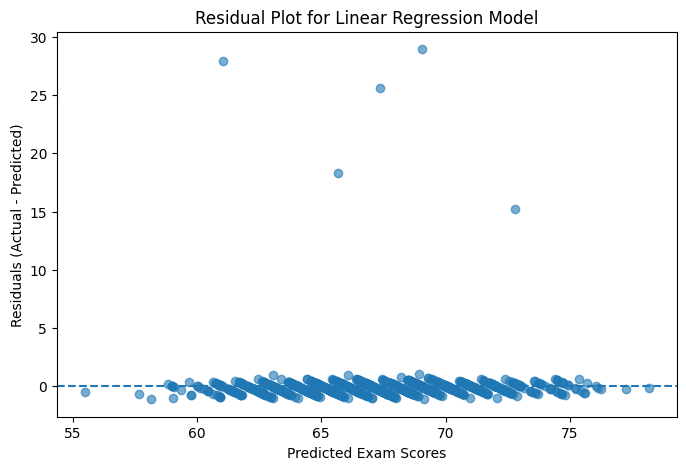

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(final_predictions, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Exam Scores")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Linear Regression Model")

plt.show()

In [75]:
# Create a dataframe for residual analysis
residual_analysis = X_test_final.copy()

residual_analysis['Actual_Score'] = y_test_final.values
residual_analysis['Predicted_Score'] = final_predictions
residual_analysis['Residual'] = residuals.values
residual_analysis['Absolute_Error'] = abs(residual_analysis['Residual'])

# Show the 10 largest prediction errors
largest_errors = residual_analysis.sort_values(
    by='Absolute_Error',
    ascending=False
).head(10)

largest_errors[
    ['Actual_Score', 'Predicted_Score', 'Residual', 'Absolute_Error']
]

,Actual_Score,Predicted_Score,Residual,Absolute_Error
6393,98,69.042561,28.957439,28.957439
217,89,61.052321,27.947679,27.947679
4583,93,67.373495,25.626505,25.626505
3932,84,65.661046,18.338954,18.338954
1607,88,72.812260,15.187740,15.187740
5160,68,69.141688,-1.141688,1.141688
2880,57,58.137661,-1.137661,1.137661
1393,71,72.079500,-1.079500,1.079500
5020,63,64.067804,-1.067804,1.067804
2118,65,66.059913,-1.059913,1.059913


In [76]:
# Identify unusually large prediction errors
outlier_threshold = 10

large_error_mask = residual_analysis['Absolute_Error'] > outlier_threshold

print("Total test observations:", len(residual_analysis))
print("Observations with error > 10 marks:", large_error_mask.sum())
print(
    "Percentage of large-error observations:",
    round(large_error_mask.mean() * 100, 2),
    "%"
)

# Performance on typical observations
typical = residual_analysis[~large_error_mask]

typical_mae = mean_absolute_error(
    typical['Actual_Score'],
    typical['Predicted_Score']
)

typical_rmse = np.sqrt(
    mean_squared_error(
        typical['Actual_Score'],
        typical['Predicted_Score']
    )
)

typical_r2 = r2_score(
    typical['Actual_Score'],
    typical['Predicted_Score']
)

print("\nPerformance excluding large-error observations:")
print("MAE:", typical_mae)
print("RMSE:", typical_rmse)
print("R2 Score:", typical_r2)

Total test observations: 1322
Observations with error > 10 marks: 5
Percentage of large-error observations: 0.38 %

Performance excluding large-error observations:
MAE: 0.32943212591259335
RMSE: 0.40508937300548614
R2 Score: 0.9852427781319479


In [77]:
from sklearn.inspection import permutation_importance

# Calculate feature importance on original columns
importance_result = permutation_importance(
    final_model,
    X_test_final,
    y_test_final,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feature_importance = pd.DataFrame({
    'Feature': X_test_final.columns,
    'Importance': importance_result.importances_mean,
    'Std_Deviation': importance_result.importances_std
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance,Std_Deviation
0,Attendance,0.800754,0.019821
1,Hours_Studied,0.487586,0.009015
2,Previous_Scores,0.075351,0.003986
3,Access_to_Resources,0.075334,0.004036
4,Parental_Involvement,0.072707,0.002831
5,Tutoring_Sessions,0.054672,0.002927
6,Family_Income,0.025774,0.002386
7,Peer_Influence,0.024027,0.001183
8,Motivation_Level,0.020932,0.002739
9,Parental_Education_Level,0.020808,0.002468


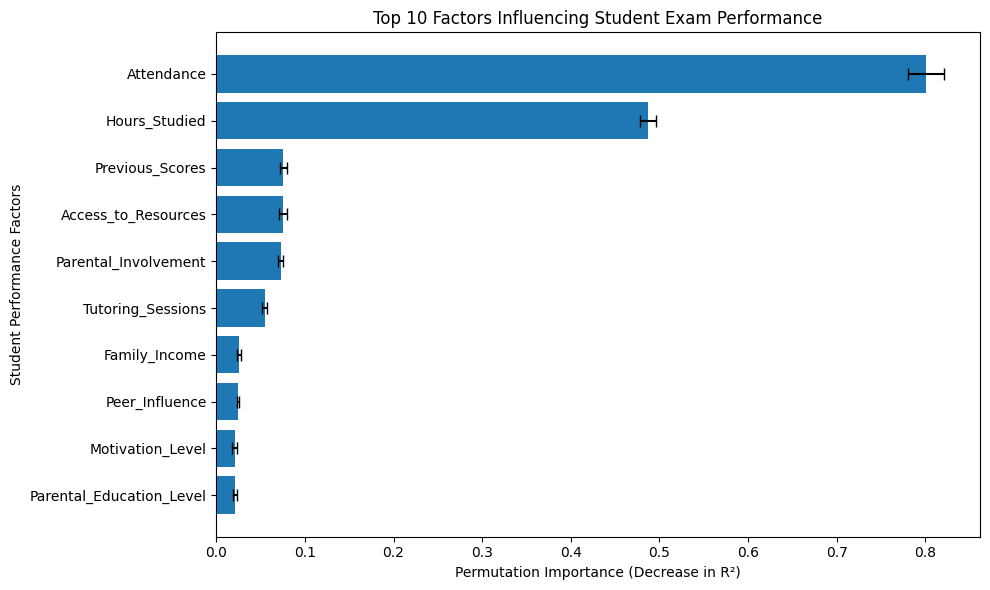

In [78]:
# Select top 10 most important features
top_features = feature_importance.head(10).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance'],
    xerr=top_features['Std_Deviation'],
    capsize=4
)

plt.xlabel("Permutation Importance (Decrease in R²)")
plt.ylabel("Student Performance Factors")
plt.title("Top 10 Factors Influencing Student Exam Performance")

plt.tight_layout()
plt.show()

In [79]:
def predict_student_performance(student_data):
    """
    Predicts the exam score of a new student
    using the trained machine learning pipeline.
    """

    # Convert student information into DataFrame
    student_df = pd.DataFrame([student_data])

    # Ensure columns are in the same order as training data
    student_df = student_df[X_raw.columns]

    # Predict exam score
    predicted_score = final_model.predict(student_df)[0]

    # Keep prediction within valid exam-score range
    predicted_score = np.clip(predicted_score, 0, 100)

    return round(predicted_score, 2)


print("Student performance prediction function created successfully!")

Student performance prediction function created successfully!


In [80]:
sample_student = {
    'Hours_Studied': 25,
    'Attendance': 85,
    'Parental_Involvement': 'Medium',
    'Access_to_Resources': 'High',
    'Extracurricular_Activities': 'Yes',
    'Sleep_Hours': 7,
    'Previous_Scores': 75,
    'Motivation_Level': 'High',
    'Internet_Access': 'Yes',
    'Tutoring_Sessions': 2,
    'Family_Income': 'Medium',
    'Teacher_Quality': 'High',
    'School_Type': 'Public',
    'Peer_Influence': 'Positive',
    'Physical_Activity': 3,
    'Learning_Disabilities': 'No',
    'Parental_Education_Level': 'College',
    'Distance_from_Home': 'Near',
    'Gender': 'Female'
}

predicted_score = predict_student_performance(sample_student)

print("Predicted Exam Score:", predicted_score)

Predicted Exam Score: 73.11


In [81]:
def generate_student_report(student_data):

    predicted_score = predict_student_performance(student_data)

    # -----------------------------
    # Determine Performance Level
    # -----------------------------
    if predicted_score >= 85:
        performance_level = "Excellent"
    elif predicted_score >= 70:
        performance_level = "Good"
    elif predicted_score >= 50:
        performance_level = "Average"
    else:
        performance_level = "Needs Improvement"


    # -----------------------------
    # Calculate Student Risk Score
    # -----------------------------
    risk_points = 0
    risk_factors = []

    if student_data["Attendance"] < 75:
        risk_points += 2
        risk_factors.append("Low attendance")

    if student_data["Hours_Studied"] < 10:
        risk_points += 2
        risk_factors.append("Insufficient study hours")

    if student_data["Previous_Scores"] < 60:
        risk_points += 2
        risk_factors.append("Low previous academic performance")

    if student_data["Motivation_Level"] == "Low":
        risk_points += 1
        risk_factors.append("Low motivation level")

    if student_data["Access_to_Resources"] == "Low":
        risk_points += 1
        risk_factors.append("Limited access to learning resources")

    if student_data["Sleep_Hours"] < 6:
        risk_points += 1
        risk_factors.append("Insufficient sleep")

    if student_data["Internet_Access"] == "No":
        risk_points += 1
        risk_factors.append("No internet access")


    # -----------------------------
    # Determine Risk Level
    # -----------------------------
    if risk_points >= 5:
        risk_level = "High Risk"
    elif risk_points >= 2:
        risk_level = "Moderate Risk"
    else:
        risk_level = "Low Risk"


    # -----------------------------
    # Generate Personalized Advice
    # -----------------------------
    recommendations = []

    if student_data["Attendance"] < 75:
        recommendations.append(
            "Improve attendance and participate regularly in academic activities."
        )

    if student_data["Hours_Studied"] < 10:
        recommendations.append(
            "Increase weekly study hours and follow a structured study schedule."
        )

    if student_data["Previous_Scores"] < 60:
        recommendations.append(
            "Review weak subjects and focus on improving previous academic gaps."
        )

    if student_data["Motivation_Level"] == "Low":
        recommendations.append(
            "Set achievable academic goals and track progress regularly."
        )

    if student_data["Access_to_Resources"] == "Low":
        recommendations.append(
            "Use additional educational resources such as libraries and online learning platforms."
        )

    if student_data["Sleep_Hours"] < 6:
        recommendations.append(
            "Maintain adequate sleep to support concentration and academic performance."
        )

    if student_data["Internet_Access"] == "No":
        recommendations.append(
            "Seek alternative access to digital educational resources."
        )

    if not recommendations:
        recommendations.append(
            "Maintain current study habits and continue monitoring academic progress."
        )


    # -----------------------------
    # Display Final Report
    # -----------------------------
    print("=" * 65)
    print("          STUDENT PERFORMANCE PREDICTION REPORT")
    print("=" * 65)

    print(f"\nPredicted Exam Score : {predicted_score}")
    print(f"Performance Level    : {performance_level}")
    print(f"Risk Assessment      : {risk_level}")
    print(f"Risk Score           : {risk_points}")

    print("\nIDENTIFIED RISK FACTORS")

    if risk_factors:
        for i, factor in enumerate(risk_factors, 1):
            print(f"{i}. {factor}")
    else:
        print("No major academic risk factors identified.")

    print("\nPERSONALIZED RECOMMENDATIONS")

    for i, recommendation in enumerate(recommendations, 1):
        print(f"{i}. {recommendation}")

    print("\n" + "=" * 65)

    return {
        "Predicted Score": predicted_score,
        "Performance Level": performance_level,
        "Risk Level": risk_level,
        "Risk Score": risk_points,
        "Risk Factors": risk_factors,
        "Recommendations": recommendations
    }


student_report = generate_student_report(sample_student)

          STUDENT PERFORMANCE PREDICTION REPORT

Predicted Exam Score : 73.11
Performance Level    : Good
Risk Assessment      : Low Risk
Risk Score           : 0

IDENTIFIED RISK FACTORS
No major academic risk factors identified.

PERSONALIZED RECOMMENDATIONS
1. Maintain current study habits and continue monitoring academic progress.



In [82]:
# Explain the prediction for the sample student

print("=" * 65)
print("              INDIVIDUAL STUDENT ANALYSIS")
print("=" * 65)

print(f"\nPredicted Exam Score: {student_report['Predicted Score']}")
print(f"Performance Level: {student_report['Performance Level']}")
print(f"Risk Level: {student_report['Risk Level']}")

print("\nKEY STUDENT FACTORS")

important_factors = [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Access_to_Resources",
    "Parental_Involvement",
    "Tutoring_Sessions"
]

for factor in important_factors:
    print(f"{factor.replace('_', ' ')}: {sample_student[factor]}")

print("\nPREDICTION INTERPRETATION")

if sample_student["Attendance"] >= 90:
    print("• High attendance positively supports academic performance.")

if sample_student["Hours_Studied"] >= 20:
    print("• Strong study commitment contributes positively to the prediction.")

if sample_student["Previous_Scores"] >= 70:
    print("• Good previous academic performance supports the predicted score.")

if sample_student["Access_to_Resources"] in ["Medium", "High"]:
    print("• Adequate access to educational resources supports learning.")

if sample_student["Tutoring_Sessions"] > 0:
    print("• Participation in tutoring provides additional academic support.")

print("\nNOTE:")
print(
    "These interpretations describe important student characteristics "
    "associated with academic performance. They should not be interpreted "
    "as causal relationships."
)

print("=" * 65)

              INDIVIDUAL STUDENT ANALYSIS

Predicted Exam Score: 73.11
Performance Level: Good
Risk Level: Low Risk

KEY STUDENT FACTORS
Attendance: 85
Hours Studied: 25
Previous Scores: 75
Access to Resources: High
Parental Involvement: Medium
Tutoring Sessions: 2

PREDICTION INTERPRETATION
• Strong study commitment contributes positively to the prediction.
• Good previous academic performance supports the predicted score.
• Adequate access to educational resources supports learning.
• Participation in tutoring provides additional academic support.

NOTE:
These interpretations describe important student characteristics associated with academic performance. They should not be interpreted as causal relationships.


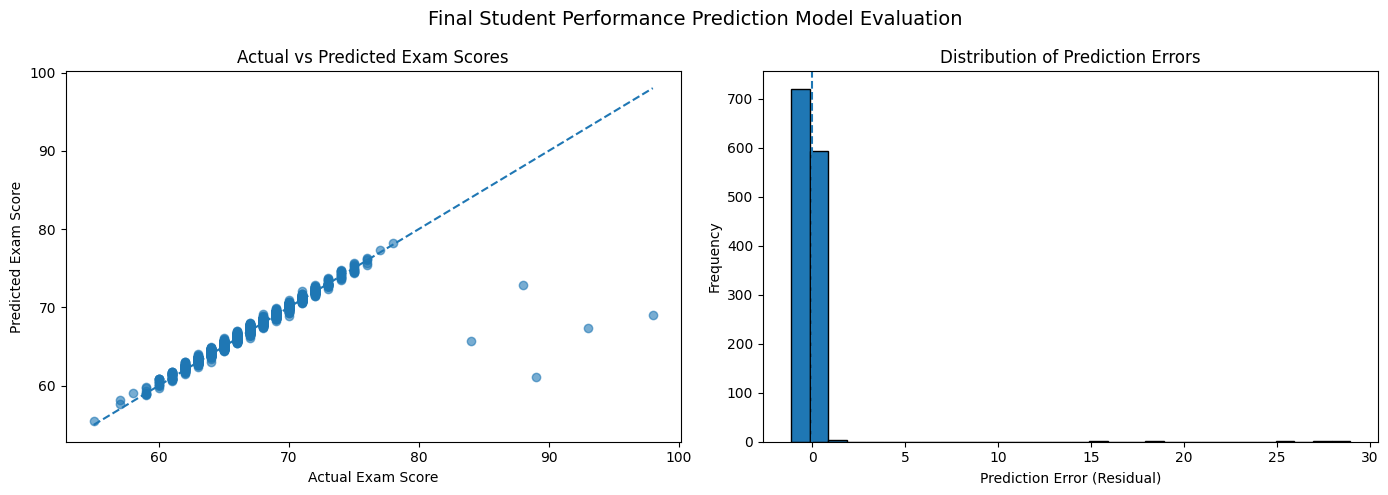

In [83]:
# Final Model Evaluation Dashboard

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Scores
axes[0].scatter(
    y_test_final,
    final_predictions,
    alpha=0.6
)

min_score = min(y_test_final.min(), final_predictions.min())
max_score = max(y_test_final.max(), final_predictions.max())

axes[0].plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

axes[0].set_xlabel("Actual Exam Score")
axes[0].set_ylabel("Predicted Exam Score")
axes[0].set_title("Actual vs Predicted Exam Scores")


# Residual Distribution
axes[1].hist(
    residuals,
    bins=30,
    edgecolor="black"
)

axes[1].axvline(
    x=0,
    linestyle="--"
)

axes[1].set_xlabel("Prediction Error (Residual)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Prediction Errors")


plt.suptitle(
    "Final Student Performance Prediction Model Evaluation",
    fontsize=14
)

plt.tight_layout()
plt.show()

Project Conclusion

This project developed an end-to-end machine learning system for predicting student examination performance using academic, behavioral, and socioeconomic factors. The workflow included data exploration, preprocessing, model development, cross-validation, model comparison, residual analysis, feature importance analysis, individual student prediction, risk assessment, and personalized recommendations.

Multiple regression algorithms were evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, Extra Trees, Ridge Regression, Lasso Regression, and ElasticNet. Based on cross-validation results, Linear and Ridge Regression demonstrated the strongest and most consistent predictive performance, achieving an average R² score of approximately 0.73.

The analysis identified attendance and hours studied as the strongest factors associated with student examination performance, followed by previous scores, access to educational resources, parental involvement, and tutoring sessions.

Residual analysis showed that the model produced relatively small prediction errors for the majority of test observations. However, a small number of unusual observations produced substantially larger errors. These observations were analyzed separately as a diagnostic step and were not removed when reporting the primary model performance metrics. This highlights an important limitation of the model and demonstrates the importance of investigating prediction errors rather than relying only on aggregate evaluation metrics.

The final system extends beyond basic score prediction by generating an individual student performance report containing the predicted examination score, performance category, academic risk assessment, identified risk factors, and personalized recommendations.

Overall, the project demonstrates a complete and interpretable machine learning workflow for student performance prediction. The system may support early identification of students who could benefit from additional academic assistance. However, predictions should be treated as decision-support information rather than definitive judgments, since student outcomes may be influenced by factors not represented in the dataset.

Future Scope

Future improvements could include evaluation on independent real-world educational datasets, more extensive hyperparameter optimization, advanced model-explanation techniques such as SHAP, fairness analysis across demographic groups, and deployment of the prediction system through an interactive web application.